<span style="font-size:8pt">*ÉTS Montréal, GPA671 : Introduction à l’intelligence artificielle. Date : le 19/08/21. Auteur : Jérôme Rony. Version : 1.0*</span>

# Laboratoire 3 : Regroupement et réduction de dimensionalité

## Exercice 1 : K-Moyennes

### Rappels de cours

L'algorithme des K-Moyennes permet de trouver une partition dure des données en K groupes. Le but de l'algorithme est de minimiser la quantité :
\begin{equation}
J = \sum_{i=1}^N\sum_{k=1}^K r_{ik}||{\bf x}_i - {\bf \mu}_k||^2
\end{equation}
où ${\bf x}_i$ est une donnée, ${\bf \mu}_k$ est le centre du groupe $k$ et $r_{ik}\in\{0, 1\}$ est un indicateur binaire qui indique à quel groupe $k$ est associée la donnée ${\bf x}_i$. Plus formellement, on peut définir cet indicateur de la manière suivante :
\begin{equation}
r_{ik} = \begin{cases}1 &\text{si}\, k = \mathrm{arg\,min}_j||{\bf x}_i - {\bf \mu}_j||^2 \\0 &\text{sinon.}\end{cases}
\end{equation}
Pour chaque exemple, on calcule donc la distance à chaque centre et on cherche l'indice du centre le plus proche.

Une fois que cette association est trouvée, on met à jour les centres ${\bf \mu}_k$ grâce à l'équation suivante:
\begin{equation}
{\bf \mu}_k = \frac{\sum_{i=1}^N r_{ik}{\bf x}_i}{\sum_{i=1}^N r_{ik}}
\end{equation}
ce qui correspond à une moyenne sur l'ensemble des données associées au centre $k$.

Enfin, on répète cette procédure jusqu'à ce que la quantité $J$ ne change plus. 

### Questions

Dans un premier temps, nous allons utiliser des données synthétiques pour observer le comportement de l'algorithme et vérifier que l'implémentation est correcte. Ensuite nous utiliserons l'algorithme des K-moyennes pour compresser une image en réduisant le nombre de couleurs utilisées pour la représenter.

2. La première étape de l'algorithme des K-Moyennes est d'initialiser les centres ${\bf \mu}_k$.
    1. Une stratégie simple pour les initialiser est de choisir aléatoirement les centres. Implémenter une **fonction** `random_init` permettant de choisir aléatoirement $K$ données parmi les toutes les données `X`. Afficher 3 centres choisis lors de 5 initialisations indépendantes avec des marqueurs différents parmi `X`. Commenter cette initialisation.    
    2. La stratégie la plus commune est appelée *k-means++* et correspond à choisir les centres un-par-un aléatoirement, avec un biais vers les points les plus éloignées des centres déjà choisis. Une fois le premier centre choisi aléatoirement, on calcule la distance entre les données `X` et le centre le plus proche. Le centre suivant est choisi aléatoirement parmi les points restant avec une probabilité proportionnelle à cette distance. On recommence ce choix jusqu'à avoir $K$ centres. Implémenter cette stratégie dans une **fonction** `kmeans_plusplus` et afficher les centres choisis lors de 5 initialisations indépendantes. Commenter cette initialisation.
    > Utiliser la fonction `numpy.random.choice` qui permet de spécifier une probabilité `p` de choisir chaque élément d'un tableau `a`.
3. Implémenter l'algorithme des K-Moyennes permettant d’utiliser n’importe quel $K$ et de choisir l'initialisation (aléatoire ou *k-means++*) dans une classe qui aura les méthodes suivantes :
    * `fit` qui prend en entrées des données `X` et applique l'algorithme des K-moyennes avec l'initialisation choisie.
    * `predict` qui prend en entrée des données `X` et renvoie le groupe prédit pour chaque échantillon.
4. Tester cet algorithme sur les données générées synthétiquement avec les deux initialisations et observer la valeur de $J$ lors des itérations de l'algorithme sur un graphique avec une échelle logarithmique pour l'axe des ordonnées. Afficher les centres obtenus ainsi que les groupes prédits pour les données pour chaque initialisationn. Commentez l'initialisation aléatoire.
5. Il est courant de recommencer l'algorithme des K-moyennes plusieurs fois pour obtenir une meilleure solution, c'est-à-dire avec une valeur de $J$ plus basse. Ajouter une méthode `fit_restart` à la classe précédente qui applique la méthode `fit` plusieurs fois (contrôlé par un paramètre `n_restart`) et garde le meilleur résultat. Comparer les résultats obtenus entre `fit_restart` avec `n_restart=5` et `fit` en utilisant l'initialisation *k-means++*.
6. Charger l'image `chelsea` depuis le paquet `skimage.data` et l'afficher. Appliquer l'algorithme de K-moyennes sur cette image avec différentes valeurs de K et afficher les images compressées pour les valeurs choisies. Pour cela il faut trouver les centres correspondant à chaque pixel de l'image puis créer une nouvelle image dont les valeurs des pixels sont celles de leur centre correspondant.
> Les images sont généralement stockées en uint8 (8 bits non signé) sur la plage d'entiers $[0, 255]$. Il faut donc commencer par les convertir en float32 et les ramener dans $[0, 1]$ ce qui peut être fait comme suit: `chelsea = data.chelsea().astype(np.float32) / 255`.

7. Recommencer avec les images `astronaut` et `coffee` de `skimage.data`. Commenter les résultats. Dans quels cas cet algorithme n'est pas adapté pour compresser des images?

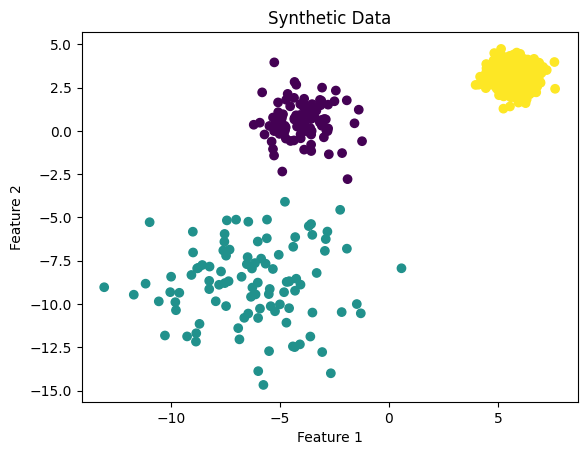

In [24]:
from sklearn import datasets

import matplotlib.pyplot as plt

# Load synthetic data
X, y = datasets.make_blobs(n_samples=[100, 100, 1000], cluster_std=[1.0, 2.5, 0.5], random_state=17)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Data')
plt.show()

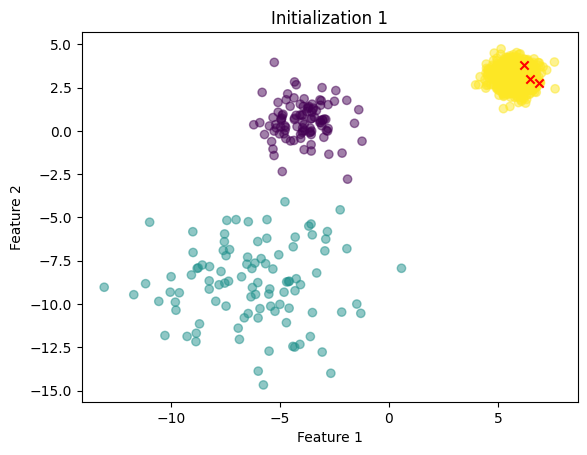

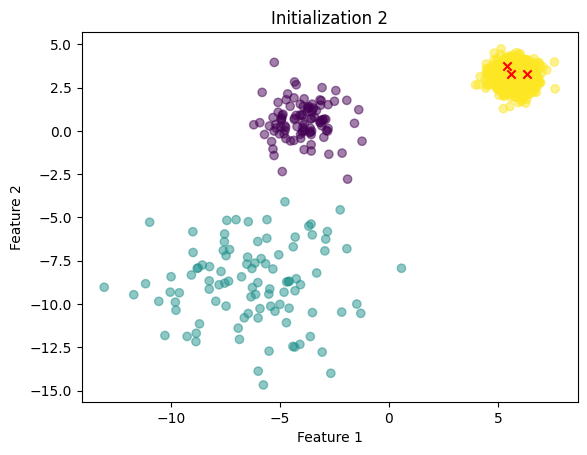

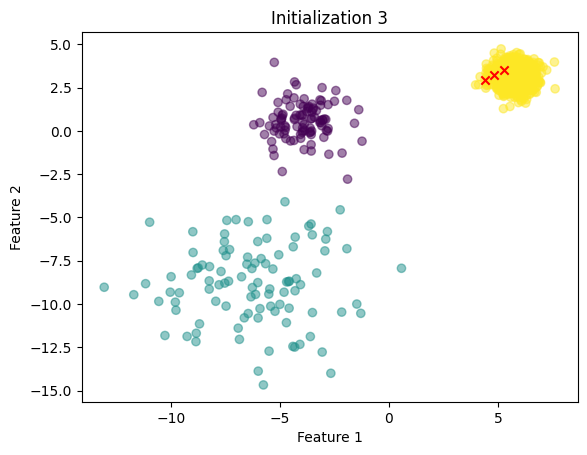

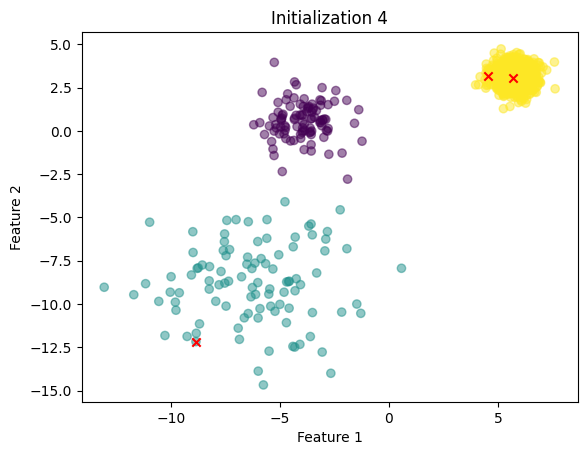

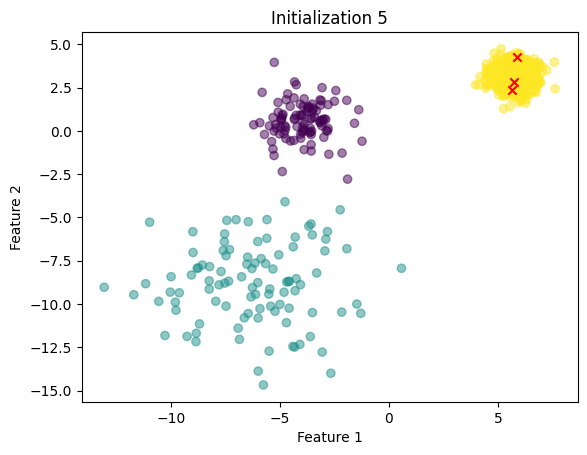

In [25]:
import numpy as np

def random_init(X, K):
    indices = np.random.choice(X.shape[0], K, replace=False)
    return X[indices]

# Number of clusters
K = 3

# Perform 5 independent initializations
for i in range(5):
    centers = random_init(X, K)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x')
    plt.title(f'Initialization {i+1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

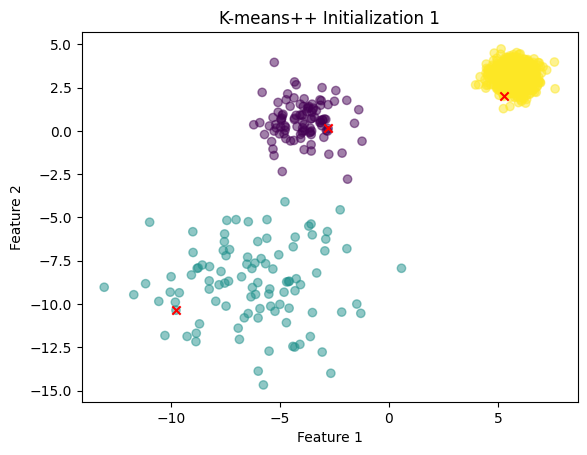

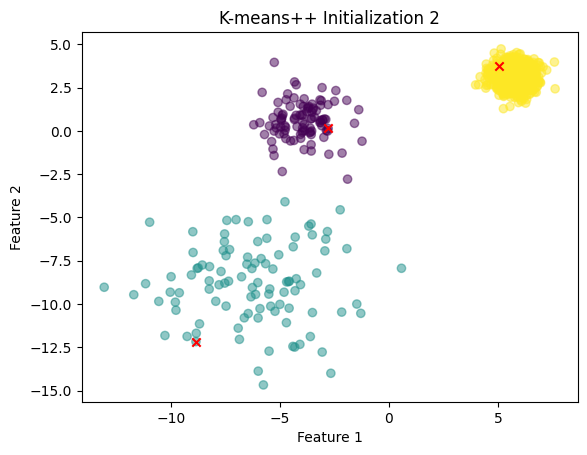

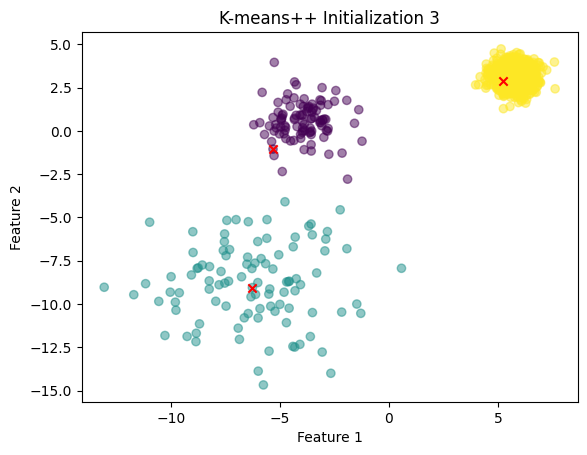

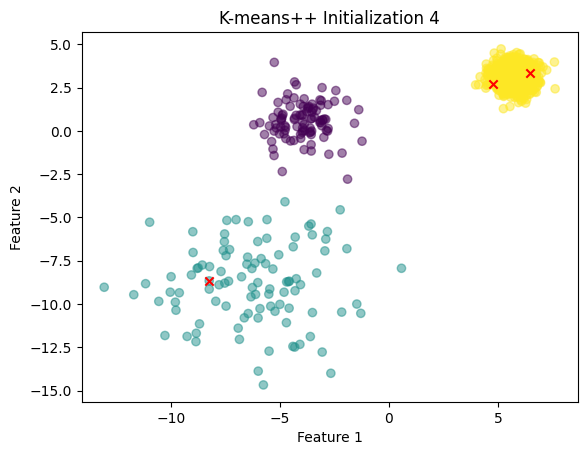

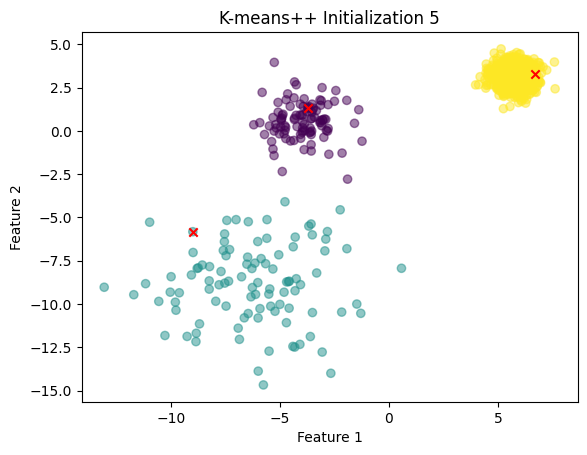

In [26]:
def kmeans_plusplus(X, K):
    centers = []
    # Choose the first center randomly
    centers.append(X[np.random.choice(X.shape[0])])
    
    for _ in range(1, K):
        # Compute the distance between each point and the nearest center
        dist_sq = np.min([np.sum((X - center) ** 2, axis=1) for center in centers], axis=0)
        # Choose the next center with a probability proportional to the distance squared
        probs = dist_sq / np.sum(dist_sq)
        cumulative_probs = np.cumsum(probs)
        r = np.random.rand()
        
        for j, p in enumerate(cumulative_probs):
            if r < p:
                centers.append(X[j])
                break
    
    return np.array(centers)

# Perform 5 independent initializations
for i in range(5):
    centers = kmeans_plusplus(X, K)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x')
    plt.title(f'K-means++ Initialization {i+1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

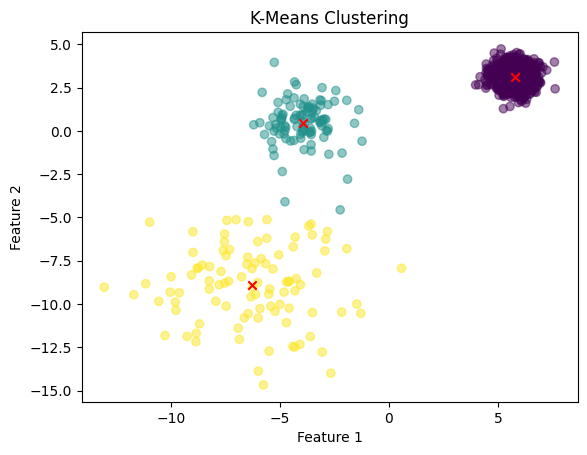

In [27]:
class KMeans:
    def __init__(self, K, init='random', max_iter=300, tol=1e-4):
        self.K = K
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.centers = None

    def initialize_centers(self, X):
        if self.init == 'random':
            return random_init(X, self.K)
        elif self.init == 'kmeans++':
            return kmeans_plusplus(X, self.K)
        else:
            raise ValueError("Unknown initialization method")

    def fit(self, X):
        self.centers = self.initialize_centers(X)
        for _ in range(self.max_iter):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
            labels = np.argmin(distances, axis=1)

            # Update centers
            new_centers = np.array([X[labels == k].mean(axis=0) for k in range(self.K)])

            # Check for convergence
            if np.linalg.norm(self.centers - new_centers) < self.tol:
                break

            self.centers = new_centers

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
        return np.argmin(distances, axis=1)

# Example usage
kmeans = KMeans(K=3, init='kmeans++')
kmeans.fit(X)
predictions = kmeans.predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.centers[:, 0], kmeans.centers[:, 1], c='red', marker='x')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

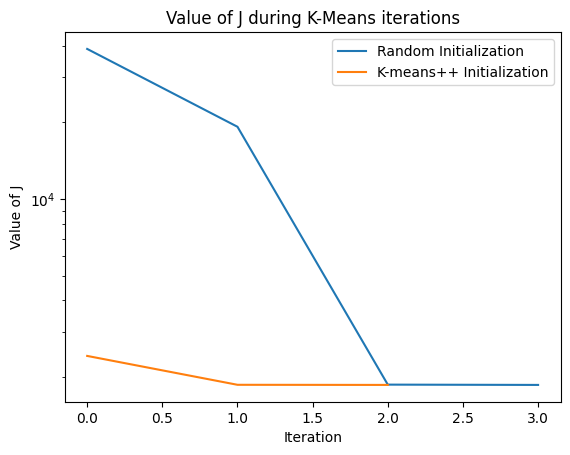

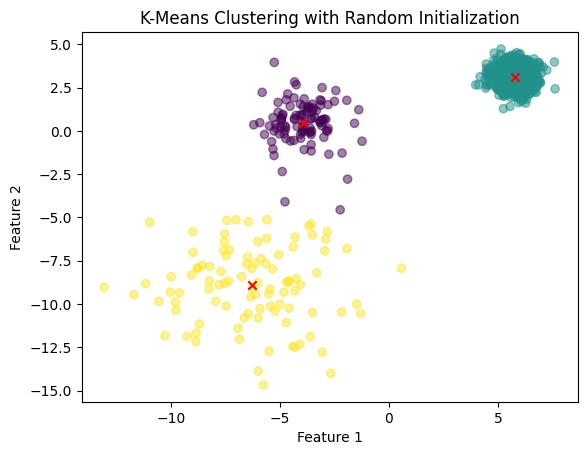

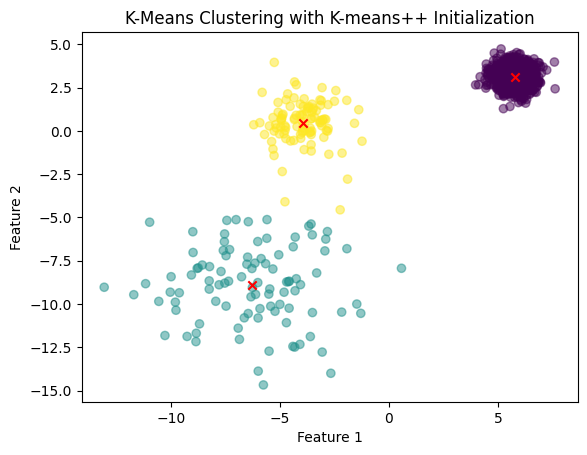

In [28]:
class KMeans:
    def __init__(self, K, init='random', max_iter=300, tol=1e-4):
        self.K = K
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.centers = None
        self.J_history = []

    def initialize_centers(self, X):
        if self.init == 'random':
            return random_init(X, self.K)
        elif self.init == 'kmeans++':
            return kmeans_plusplus(X, self.K)
        else:
            raise ValueError("Unknown initialization method")

    def fit(self, X):
        self.centers = self.initialize_centers(X)
        for _ in range(self.max_iter):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
            labels = np.argmin(distances, axis=1)

            # Compute the value of J
            J = np.sum([np.sum((X[labels == k] - self.centers[k]) ** 2) for k in range(self.K)])
            self.J_history.append(J)

            # Update centers
            new_centers = np.array([X[labels == k].mean(axis=0) for k in range(self.K)])

            # Check for convergence
            if np.linalg.norm(self.centers - new_centers) < self.tol:
                break

            self.centers = new_centers

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
        return np.argmin(distances, axis=1)

# Test with random initialization
kmeans_random = KMeans(K=3, init='random')
kmeans_random.fit(X)
predictions_random = kmeans_random.predict(X)

# Test with kmeans++ initialization
kmeans_plus = KMeans(K=3, init='kmeans++')
kmeans_plus.fit(X)
predictions_plus = kmeans_plus.predict(X)

# Plot the value of J for both initializations
plt.plot(kmeans_random.J_history, label='Random Initialization')
plt.plot(kmeans_plus.J_history, label='K-means++ Initialization')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Value of J')
plt.title('Value of J during K-Means iterations')
plt.legend()
plt.show()

# Plot the results for random initialization
plt.scatter(X[:, 0], X[:, 1], c=predictions_random, cmap='viridis', alpha=0.5)
plt.scatter(kmeans_random.centers[:, 0], kmeans_random.centers[:, 1], c='red', marker='x')
plt.title('K-Means Clustering with Random Initialization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Plot the results for kmeans++ initialization
plt.scatter(X[:, 0], X[:, 1], c=predictions_plus, cmap='viridis', alpha=0.5)
plt.scatter(kmeans_plus.centers[:, 0], kmeans_plus.centers[:, 1], c='red', marker='x')
plt.title('K-Means Clustering with K-means++ Initialization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

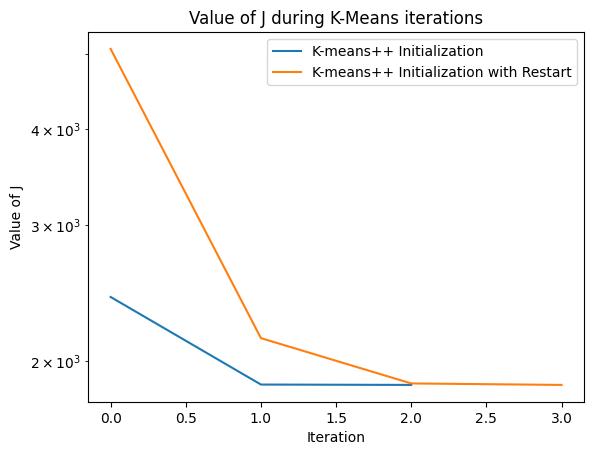

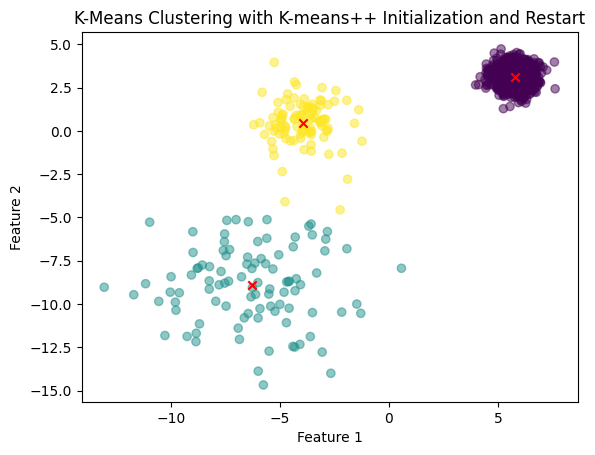

In [29]:
class KMeans:
    def __init__(self, K, init='random', max_iter=300, tol=1e-4):
        self.K = K
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.centers = None
        self.J_history = []

    def initialize_centers(self, X):
        if self.init == 'random':
            return random_init(X, self.K)
        elif self.init == 'kmeans++':
            return kmeans_plusplus(X, self.K)
        else:
            raise ValueError("Unknown initialization method")

    def fit(self, X):
        self.centers = self.initialize_centers(X)
        self.J_history = []
        for _ in range(self.max_iter):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
            labels = np.argmin(distances, axis=1)

            # Compute the value of J
            J = np.sum([np.sum((X[labels == k] - self.centers[k]) ** 2) for k in range(self.K)])
            self.J_history.append(J)

            # Update centers
            new_centers = np.array([X[labels == k].mean(axis=0) for k in range(self.K)])

            # Check for convergence
            if np.linalg.norm(self.centers - new_centers) < self.tol:
                break

            self.centers = new_centers

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
        return np.argmin(distances, axis=1)

    def fit_restart(self, X, n_restart=5):
        best_J = float('inf')
        best_centers = None
        best_J_history = None

        for _ in range(n_restart):
            self.fit(X)
            if self.J_history[-1] < best_J:
                best_J = self.J_history[-1]
                best_centers = self.centers
                best_J_history = self.J_history

        self.centers = best_centers
        self.J_history = best_J_history

# Compare the results
kmeans_restart = KMeans(K=3, init='kmeans++')
kmeans_restart.fit_restart(X, n_restart=5)
predictions_restart = kmeans_restart.predict(X)

# Plot the value of J for fit and fit_restart
plt.plot(kmeans_plus.J_history, label='K-means++ Initialization')
plt.plot(kmeans_restart.J_history, label='K-means++ Initialization with Restart')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Value of J')
plt.title('Value of J during K-Means iterations')
plt.legend()
plt.show()

# Plot the results for kmeans++ initialization with restart
plt.scatter(X[:, 0], X[:, 1], c=predictions_restart, cmap='viridis', alpha=0.5)
plt.scatter(kmeans_restart.centers[:, 0], kmeans_restart.centers[:, 1], c='red', marker='x')
plt.title('K-Means Clustering with K-means++ Initialization and Restart')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

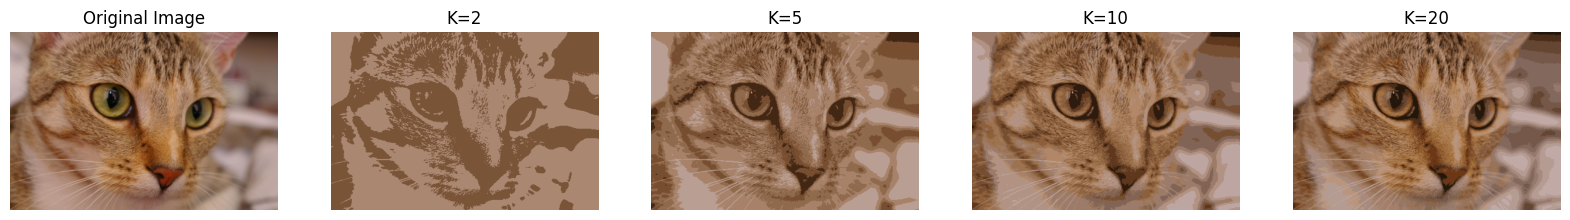

In [30]:
from skimage import data
import numpy as np

import matplotlib.pyplot as plt

# Load the image
chelsea = data.chelsea().astype(np.float32) / 255

# Reshape the image to a 2D array of pixels
pixels = chelsea.reshape(-1, 3)

# Apply K-means with different values of K
K_values = [2, 5, 10, 20]
compressed_images = []

for K in K_values:
    kmeans = KMeans(K=K, init='kmeans++')
    kmeans.fit(pixels)
    new_pixels = kmeans.centers[kmeans.predict(pixels)]
    compressed_image = new_pixels.reshape(chelsea.shape)
    compressed_images.append(compressed_image)

# Plot the original and compressed images
fig, axes = plt.subplots(1, len(K_values) + 1, figsize=(20, 5))
axes[0].imshow(chelsea)
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, K in enumerate(K_values):
    axes[i + 1].imshow(compressed_images[i])
    axes[i + 1].set_title(f'K={K}')
    axes[i + 1].axis('off')

plt.show()

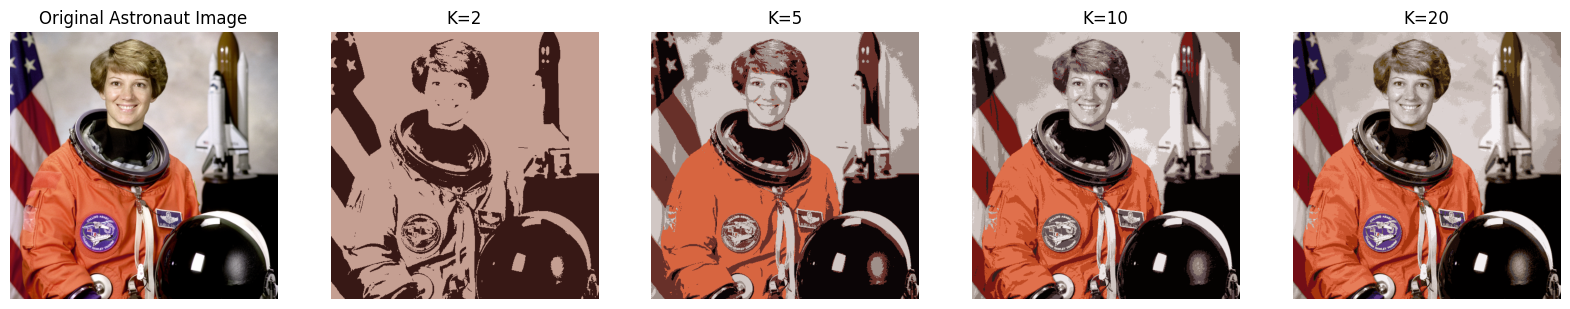

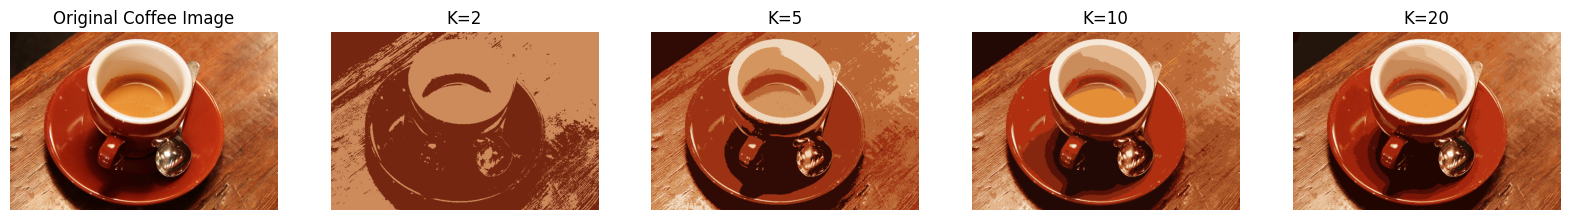

In [31]:
# Load the images
astronaut = data.astronaut().astype(np.float32) / 255
coffee = data.coffee().astype(np.float32) / 255

# Reshape the images to 2D arrays of pixels
astronaut_pixels = astronaut.reshape(-1, 3)
coffee_pixels = coffee.reshape(-1, 3)

# Apply K-means with different values of K
compressed_astronaut_images = []
compressed_coffee_images = []

for K in K_values:
    kmeans_astronaut = KMeans(K=K, init='kmeans++')
    kmeans_astronaut.fit(astronaut_pixels)
    new_astronaut_pixels = kmeans_astronaut.centers[kmeans_astronaut.predict(astronaut_pixels)]
    compressed_astronaut_image = new_astronaut_pixels.reshape(astronaut.shape)
    compressed_astronaut_images.append(compressed_astronaut_image)

    kmeans_coffee = KMeans(K=K, init='kmeans++')
    kmeans_coffee.fit(coffee_pixels)
    new_coffee_pixels = kmeans_coffee.centers[kmeans_coffee.predict(coffee_pixels)]
    compressed_coffee_image = new_coffee_pixels.reshape(coffee.shape)
    compressed_coffee_images.append(compressed_coffee_image)

# Plot the original and compressed images for astronaut
fig, axes = plt.subplots(1, len(K_values) + 1, figsize=(20, 5))
axes[0].imshow(astronaut)
axes[0].set_title('Original Astronaut Image')
axes[0].axis('off')

for i, K in enumerate(K_values):
    axes[i + 1].imshow(compressed_astronaut_images[i])
    axes[i + 1].set_title(f'K={K}')
    axes[i + 1].axis('off')

plt.show()

# Plot the original and compressed images for coffee
fig, axes = plt.subplots(1, len(K_values) + 1, figsize=(20, 5))
axes[0].imshow(coffee)
axes[0].set_title('Original Coffee Image')
axes[0].axis('off')

for i, K in enumerate(K_values):
    axes[i + 1].imshow(compressed_coffee_images[i])
    axes[i + 1].set_title(f'K={K}')
    axes[i + 1].axis('off')

plt.show()

## Exercice 2 : Réduction de dimensionnalité avec PCA

### Rappels de cours

L'analyse en composantes principales permet de réduire la dimensionnalité d'un problème en choisissant des directions orthogonales selon lesquelles les données ont la variance la plus élevée dans l'espace d'entrée.

Afin de calculer ces directions, la première étape est de centrer les données $X\in\mathbb{R}^{n\times d}$ :
\begin{equation}
\tilde{X} = X - \bar{X} \qquad \bar{X} = \frac{1}{n}\sum_{i=1}^n X_i
\end{equation}
Ensuite, on calcule la matrice de covariance $C\in\mathbb{R}^{d\times d}$ des composantes de X:
\begin{equation}
C = \mathrm{cov}(\tilde{X}, \tilde{X}) = \tilde{X}^\top \tilde{X}
\end{equation}
Une fois la matrice de covariance obtenue, on cherche les valeurs propres et vecteurs propres de $C$, c’est-à-dire les valeurs $\lambda \in \mathbb{R}$ et vecteurs ${\bf \varphi}\in\mathbb{R}^{d}$ tels que $C{\bf \varphi}=\lambda {\bf \varphi}$.

On peut alors projeter les données centrées dans un espace de dimension réduite (ici $p$):
\begin{equation}
Z = \tilde{X} \Phi \qquad \Phi = [\varphi_1, \varphi_2, \dots, \varphi_p] \in \mathbb{R}^{d\times p}
\end{equation}

On peut enfin reconstruire les données originales comme suit:
\begin{equation}
\hat{X} = Z\Phi^\top + \bar{X}
\end{equation}

### Questions

Dans cet exercice, on cherche à trouver des groupes d'images dans une banque d'images. Plus spécifiquement, nous allons utiliser le jeu de données de visages *Olivetti* qui contient 10 photos des visages de 40 personnes, soit 400 images au total.

1. Charger le jeu de données *Olivetti* à l'aide de `sklearn.datasets.fetch_olivetti_faces`. Afficher 5 images choisies aléatoirement. Séparer les données en une base d'entrainement et une base de test avec une proportion de 40% pour l'entrainement et 60% pour le test.
> Attention à bien utiliser l'option `stratify` de `sklearn.model_selection.train_test_split` pour assurer que toutes les étiquettes se retrouvent dans l'entrainement et le test.
2. Entraîner un classifieur naïf Bayésien à l'aide de `sklearn.naive_bayes.GaussianNB` sur les données d'entraînement brutes et calculer le taux d'exactitude sur les données de test.
3. Calculer les valeurs propres et vecteurs propres de la matrice de covariance des données d'entraînement. Afficher la somme cumulative normalisée des valeurs propres ordonnées par ordre décroissant. À quoi correspond cette somme cumulée?
> La matrice de covariance étant symmétrique, on peut utilise `numpy.linalg.eigh` qui est plus rapide que `numpy.linalg.eig`.
4. Afficher les 10 premiers vecteurs propres sous forme d'image (remarquer la dimension identique aux images originales). Que représentent ces images?
5. Projeter les données d'entrainement sur les 5 premiers vecteurs propres correspondant aux 5 plus grandes valeurs propres. Reconstruire 8 images aléatoirement choisies et les afficher en dessous des 8 images originales correspondantes. Que se passe-t-il lorsqu'on projette les données sur un plus grand nombre de vecteurs propres? Plus petit?
6. Entrainer un classifieur naïf Bayésien sur les données projetées sur les 10 premiers vecteurs propres et évaluer sa performance sur les données de test.
7. Étudier la performance du classifieur naïf Bayésien en fonction du nombre de valeurs propres utilisées pour la projection. Mesurer le taux d'exactitude ainsi que les temps d'entrainement d'inférence. Conclure sur le choix du nombre de vecteurs propres à utiliser lors de la projection.
8. Utiliser la méthode `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` qui effectue une réduction de dimensionnalité **et** entraine un classifieur naïf Bayésien. Comparer le taux d'exactitude obtenu ainsi que le temps d'inférence avec la solution précédemment choisie. Expliquer.

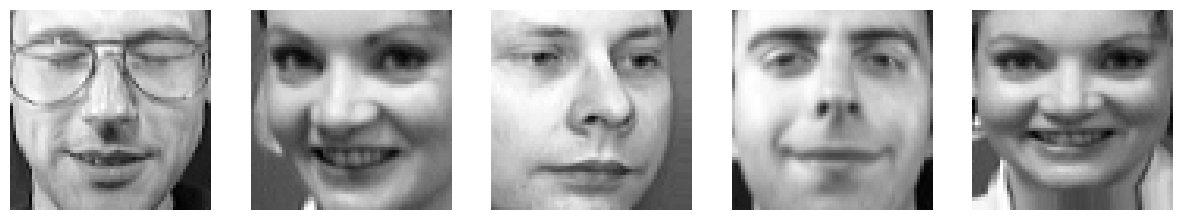

In [32]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Load the Olivetti faces dataset
faces = fetch_olivetti_faces()
X_faces = faces.data
y_faces = faces.target

# Display 5 random images
random_indices = np.random.choice(X_faces.shape[0], 5, replace=False)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, idx in zip(axes, random_indices):
    ax.imshow(X_faces[idx].reshape(64, 64), cmap='gray')
    ax.axis('off')
plt.show()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_faces, y_faces, test_size=0.6, stratify=y_faces, random_state=42)

In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the classifier on the training data
gnb.fit(X_train, y_train)

# Predict the labels for the test data
y_pred = gnb.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 56.25%


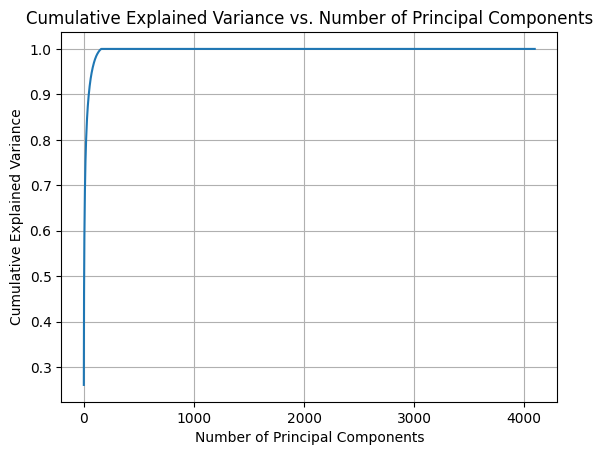

In [34]:
# Center the data
X_train_centered = X_train - np.mean(X_train, axis=0)

# Compute the covariance matrix
cov_matrix = np.cov(X_train_centered, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort the eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Compute the cumulative sum of the normalized eigenvalues
cumulative_sum = np.cumsum(eigenvalues) / np.sum(eigenvalues)

# Plot the cumulative sum of the normalized eigenvalues
plt.plot(cumulative_sum)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.grid(True)
plt.show()

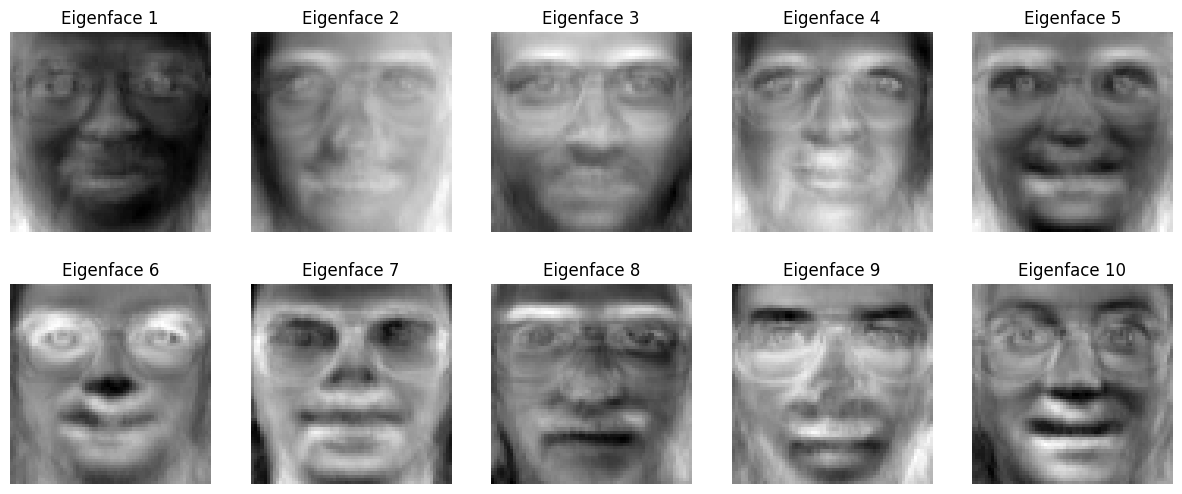

In [35]:
# Reshape the first 10 eigenvectors to the original image dimensions
eigenfaces = eigenvectors[:, :10].reshape((64, 64, 10))

# Plot the first 10 eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[:, :, i], cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.show()

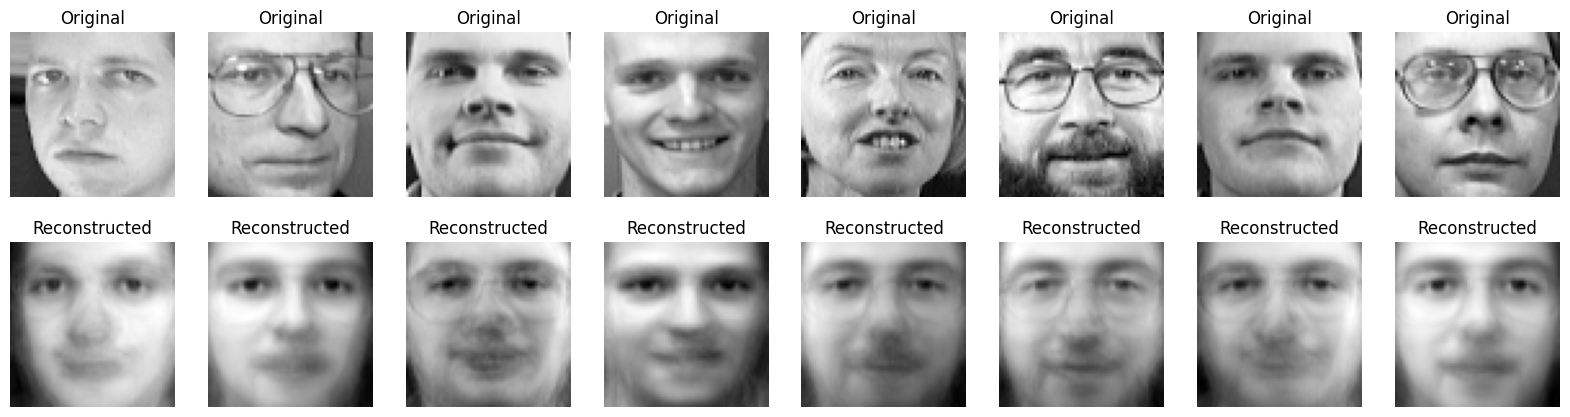

In [36]:
# Number of principal components to use
n_components = 5

# Project the training data onto the first n_components eigenvectors
X_train_pca = np.dot(X_train_centered, eigenvectors[:, :n_components])

# Reconstruct the images from the projections
X_train_reconstructed = np.dot(X_train_pca, eigenvectors[:, :n_components].T) + np.mean(X_train, axis=0)

# Select 8 random images to display
random_indices = np.random.choice(X_train.shape[0], 8, replace=False)

# Plot the original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, idx in enumerate(random_indices):
    # Original image
    axes[0, i].imshow(X_train[idx].reshape(64, 64), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')

    # Reconstructed image
    axes[1, i].imshow(X_train_reconstructed[idx].reshape(64, 64), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed')

plt.show()

In [37]:
# Number of principal components to use
n_components = 10

# Project the training data onto the first n_components eigenvectors
X_train_pca = np.dot(X_train_centered, eigenvectors[:, :n_components])

# Center the test data
X_test_centered = X_test - np.mean(X_train, axis=0)

# Project the test data onto the first n_components eigenvectors
X_test_pca = np.dot(X_test_centered, eigenvectors[:, :n_components])

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the classifier on the projected training data
gnb.fit(X_train_pca, y_train)

# Predict the labels for the projected test data
y_pred_pca = gnb.predict(X_test_pca)

# Calculate the accuracy
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy with 10 principal components: {accuracy_pca * 100:.2f}%')

Accuracy with 10 principal components: 67.08%


In [38]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import time

# Initialize the Linear Discriminant Analysis model
lda = LinearDiscriminantAnalysis()

# Train the LDA model on the training data
start_time = time.time()
lda.fit(X_train, y_train)
training_time = time.time() - start_time

# Predict the labels for the test data
start_time = time.time()
y_pred_lda = lda.predict(X_test)
inference_time = time.time() - start_time

# Calculate the accuracy
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f'Accuracy with LDA: {accuracy_lda * 100:.2f}%')
print(f'Training time with LDA: {training_time:.4f} seconds')
print(f'Inference time with LDA: {inference_time:.4f} seconds')

# Compare with the previous PCA + GaussianNB results
print(f'Accuracy with PCA: {accuracy_pca * 100:.2f}%')

Accuracy with LDA: 88.33%
Training time with LDA: 0.1682 seconds
Inference time with LDA: 0.0035 seconds
Accuracy with PCA: 67.08%
